In [48]:
from __future__ import annotations
import polars as pl
import matplotlib.pyplot as plt
CANDLES_DATA_DIR = (
    "../data/market/v1/candles/"
    "venue=OKX/"
    "instrument_id=*/"
    "bar_type=1m/"
    "year=*/"
    "month=*/"
    "data.parquet"
)

Matplotlib is building the font cache; this may take a moment.


In [ ]:
schema = pl.read_parquet_schema(CANDLES_DATA_DIR)
schema

Schema([('venue', String),
        ('instrument_id', String),
        ('bar_type', String),
        ('timestamp', Datetime(time_unit='ms', time_zone='UTC')),
        ('open', Float64),
        ('high', Float64),
        ('low', Float64),
        ('close', Float64),
        ('volume', Float64),
        ('volume_ccy', Float64),
        ('volume_quote', Float64),
        ('confirm', Int8)])

In [ ]:
df =  pl.read_parquet(CANDLES_DATA_DIR)
df

venue,instrument_id,bar_type,timestamp,open,high,low,close,volume,volume_ccy,volume_quote,confirm
str,str,str,"datetime[ms, UTC]",f64,f64,f64,f64,f64,f64,f64,i8
"""OKX""","""AAPL-USDT-SWAP""","""1m""",2026-03-04 08:15:00 UTC,257.9,264.3,257.9,263.63,15.79,15.79,4158.6313,1
"""OKX""","""AAPL-USDT-SWAP""","""1m""",2026-03-04 08:16:00 UTC,263.59,263.64,263.25,263.3,17.57,17.57,4629.4652,1
"""OKX""","""AAPL-USDT-SWAP""","""1m""",2026-03-04 08:17:00 UTC,263.62,263.62,263.3,263.3,1.07,1.07,281.7438,1
"""OKX""","""AAPL-USDT-SWAP""","""1m""",2026-03-04 08:18:00 UTC,263.3,263.62,263.3,263.62,1.54,1.54,405.628,1
"""OKX""","""AAPL-USDT-SWAP""","""1m""",2026-03-04 08:19:00 UTC,263.83,263.83,263.39,263.82,1.19,1.19,313.4939,1
…,…,…,…,…,…,…,…,…,…,…,…
"""OKX""","""ZEC-USDT-SWAP""","""1m""",2026-07-19 10:17:00 UTC,559.61,559.82,559.61,559.74,7432.0,74.32,41596.795,1
"""OKX""","""ZEC-USDT-SWAP""","""1m""",2026-07-19 10:18:00 UTC,559.74,559.94,559.73,559.94,2077.0,20.77,11626.0346,1
"""OKX""","""ZEC-USDT-SWAP""","""1m""",2026-07-19 10:19:00 UTC,559.95,560.19,559.95,560.16,2765.0,27.65,15485.6352,1


In [ ]:
df = (
    df.sort(["instrument_id", "timestamp"])
    .unique(subset=["instrument_id", "timestamp"], keep="last", maintain_order=True)
    .group_by_dynamic(
        "timestamp", every="1h", group_by="instrument_id", closed="left", label="left"
    )
    .agg(
        pl.col("open").first().alias("open"),
        pl.col("high").max().alias("high"),
        pl.col("low").min().alias("low"),
        pl.col("close").last().alias("close"),
        pl.col("volume").sum().alias("volume"),
    ).sort(["timestamp", "instrument_id"])
)
df

instrument_id,timestamp,open,high,low,close,volume
str,"datetime[ms, UTC]",f64,f64,f64,f64,f64
"""BCH-USDT-SWAP""",2020-01-01 00:00:00 UTC,205.1,205.98,204.89,205.18,1163.0
"""BTC-USDT-SWAP""",2020-01-01 00:00:00 UTC,7192.9,7193.5,7176.7,7176.8,461065.0
"""ETH-USDT-SWAP""",2020-01-01 00:00:00 UTC,129.14,129.14,128.73,128.88,5.406759e6
"""XRP-USDT-SWAP""",2020-01-01 00:00:00 UTC,0.1924,0.1927,0.192,0.1922,443.0
"""BCH-USDT-SWAP""",2020-01-01 01:00:00 UTC,205.05,208.48,204.82,206.35,1214.0
…,…,…,…,…,…,…
"""WLD-USDT-SWAP""",2026-07-19 10:00:00 UTC,0.3763,0.3764,0.3746,0.3748,822786.0
"""XAG-USDT-SWAP""",2026-07-19 10:00:00 UTC,56.09,56.1,56.06,56.07,27207.0
"""XAU-USDT-SWAP""",2026-07-19 10:00:00 UTC,4017.0,4017.1,4017.0,4017.1,13940.0


In [ ]:
df = df.with_columns(
    pl.col("volume")
    .rolling_mean(window_size=30)
    .over("instrument_id")
    .alias("trail_volume")
).filter(pl.col("trail_volume").is_not_null())
df

instrument_id,timestamp,open,high,low,close,volume,trail_volume
str,"datetime[ms, UTC]",f64,f64,f64,f64,f64,f64
"""BCH-USDT-SWAP""",2020-01-02 05:00:00 UTC,201.28,202.56,200.97,201.86,889.0,2972.533333
"""BTC-USDT-SWAP""",2020-01-02 05:00:00 UTC,7143.7,7152.7,7130.5,7137.3,1.038333e6,784141.5
"""ETH-USDT-SWAP""",2020-01-02 05:00:00 UTC,129.61,129.71,129.3,129.57,5.938559e6,5.4560e6
"""XRP-USDT-SWAP""",2020-01-02 05:00:00 UTC,0.1909,0.1911,0.1908,0.191,453.0,590.2
"""BCH-USDT-SWAP""",2020-01-02 06:00:00 UTC,201.86,202.38,201.15,201.49,574.0,2952.9
…,…,…,…,…,…,…,…
"""WLD-USDT-SWAP""",2026-07-19 10:00:00 UTC,0.3763,0.3764,0.3746,0.3748,822786.0,7.1589e6
"""XAG-USDT-SWAP""",2026-07-19 10:00:00 UTC,56.09,56.1,56.06,56.07,27207.0,323775.033333
"""XAU-USDT-SWAP""",2026-07-19 10:00:00 UTC,4017.0,4017.1,4017.0,4017.1,13940.0,289272.566667


In [ ]:
trading_universe_size = 30
df = (df.with_columns(
    pl.col("trail_volume")
    .rank(method="ordinal", descending=True)
    .over("timestamp")
    .alias("volume_rank"),
    (
        pl.col("trail_volume").rank(method="ordinal", descending=True).over("timestamp")
        <= trading_universe_size
    ).alias("is_universe"),
)).sort(["timestamp", "volume_rank"])
df

instrument_id,timestamp,open,high,low,close,volume,trail_volume,volume_rank,is_universe
str,"datetime[ms, UTC]",f64,f64,f64,f64,f64,f64,u32,bool
"""ETH-USDT-SWAP""",2020-01-02 05:00:00 UTC,129.61,129.71,129.3,129.57,5.938559e6,5.4560e6,1,true
"""BTC-USDT-SWAP""",2020-01-02 05:00:00 UTC,7143.7,7152.7,7130.5,7137.3,1.038333e6,784141.5,2,true
"""BCH-USDT-SWAP""",2020-01-02 05:00:00 UTC,201.28,202.56,200.97,201.86,889.0,2972.533333,3,true
"""XRP-USDT-SWAP""",2020-01-02 05:00:00 UTC,0.1909,0.1911,0.1908,0.191,453.0,590.2,4,true
"""ETH-USDT-SWAP""",2020-01-02 06:00:00 UTC,129.47,129.86,129.19,129.4,6.889204e6,5.5054e6,1,true
…,…,…,…,…,…,…,…,…,…
"""MU-USDT-SWAP""",2026-07-19 10:00:00 UTC,850.73,850.96,848.24,849.67,552.48,1376.513333,46,false
"""MRVL-USDT-SWAP""",2026-07-19 10:00:00 UTC,188.62,188.89,188.05,188.23,500.56,803.888333,47,false
"""SAMSUNG-USDT-SWAP""",2026-07-19 10:00:00 UTC,169.28,169.32,167.98,168.34,560.64,471.562667,48,false


In [50]:
universe_counts = (
    df
    .group_by(["timestamp", "is_universe"])
    .len(name="count")
    .sort("timestamp")
)
universe_counts

timestamp,is_universe,count
"datetime[ms, UTC]",bool,u32
2020-01-02 05:00:00 UTC,true,4
2020-01-02 06:00:00 UTC,true,4
2020-01-02 07:00:00 UTC,true,4
2020-01-02 08:00:00 UTC,true,4
2020-01-02 09:00:00 UTC,true,4
…,…,…
2026-07-19 08:00:00 UTC,true,30
2026-07-19 09:00:00 UTC,false,20
2026-07-19 09:00:00 UTC,true,30


6.548630136986302 3407


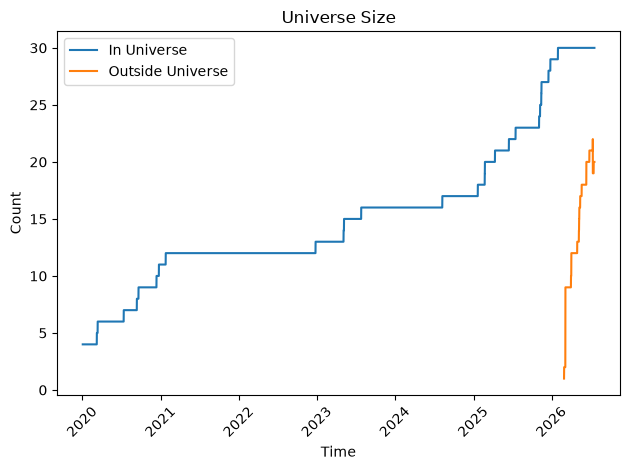

In [ ]:
counts = (
    universe_counts
    .to_pandas()
)
inside = counts[counts["is_universe"] == 1]
outside = counts[counts["is_universe"] == 0]
plt.plot(
    inside["timestamp"],
    inside["count"],
    label="In Universe",
)
plt.plot(
    outside["timestamp"],
    outside["count"],
    label="Outside Universe",
)
plt.title("Universe Size")
plt.xlabel("Time")
plt.ylabel("Count")
plt.legend()
#plt.xticks([])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()